# TimeGAN sobre régimen homogéneo alineado con Conv1D Hybrid Detector

In [1]:
import os
import json
import math
import joblib
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

## Reproducibilidad

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Cargar configuración del detector objetivo

In [3]:
PROJECT_ROOT = Path("..").resolve()

detector_config_path = PROJECT_ROOT / "models" / "detectors" / "conv1d_hybrid_ae" / "config.json"

with open(detector_config_path, "r") as f:
    detector_config = json.load(f)

detector_config

{'model_name': 'conv1d_hybrid_ae',
 'best_params_from_optuna': {'window_size': 60,
  'stride': 1,
  'n_conv_layers': 1,
  'conv_channels_1': 64,
  'conv_channels_2': 16,
  'conv_channels_3': 8,
  'kernel_size': 5,
  'disc_hidden_1': 64,
  'disc_hidden_2': 16,
  'fusion_hidden': 256,
  'dropout': 0.01837443752413843,
  'batch_size': 128,
  'lr': 0.00023729585064585673,
  'optimizer': 'Adam',
  'epochs': 30},
 'continuous_cols': ['AIT201.Pv',
  'AIT202.Pv',
  'AIT203.Pv',
  'AIT501.Pv',
  'AIT502.Pv',
  'AIT503.Pv',
  'AIT504.Pv',
  'DPIT301.Pv',
  'FIT101.Pv',
  'FIT201.Pv',
  'FIT301.Pv',
  'FIT401.Pv',
  'FIT501.Pv',
  'FIT502.Pv',
  'FIT503.Pv',
  'FIT504.Pv',
  'FIT601.Pv',
  'LIT101.Pv',
  'LIT301.Pv',
  'LIT401.Pv',
  'PIT501.Pv',
  'PIT502.Pv',
  'PIT503.Pv'],
 'discrete_cols': ['MV101.Status',
  'MV201.Status',
  'MV301.Status',
  'MV302.Status',
  'MV303.Status',
  'MV304.Status',
  'MV501.Status',
  'MV502.Status',
  'MV503.Status',
  'MV504.Status',
  'P101.Status',
  'P201.S

In [4]:
continuous_cols = detector_config["continuous_cols"]
discrete_cols = detector_config["discrete_cols"]
feature_cols = detector_config["feature_cols"]

WINDOW_SIZE = detector_config["window_size"]
WARMUP = detector_config["warmup"]

# En este experimento fijamos stride=5 porque fue la versión más sana del baseline
STRIDE = 5

print("Window size:", WINDOW_SIZE)
print("Stride:", STRIDE)
print("Warmup:", WARMUP)
print("Continuous:", len(continuous_cols))
print("Discrete:", len(discrete_cols))

Window size: 60
Stride: 5
Warmup: 120
Continuous: 23
Discrete: 26


## Configuración base de TimeGAN para este experimento

In [5]:
BEST_PARAMS = {
    "hidden_dim": 128,
    "latent_dim": 64,
    "num_layers": 3,
    "eta": 100,
    "lambda_r": 1.0,
    "lambda_s": 1.0,
    "lambda_m": 25,
    "lr_e": 1e-3,
    "lr_s": 1e-3,
    "lr_g": 5e-4,
    "lr_d": 1e-4,
    "gamma": 1,
    "epochs_embedder": 50,
    "epochs_supervisor": 50,
    "epochs_joint": 150,
    "batch_size": 128
}

seq_len = WINDOW_SIZE
hidden_dim = BEST_PARAMS["hidden_dim"]
latent_dim = BEST_PARAMS["latent_dim"]
num_layers = BEST_PARAMS["num_layers"]

epochs_embedder = BEST_PARAMS["epochs_embedder"]
epochs_supervisor = BEST_PARAMS["epochs_supervisor"]
epochs_joint = BEST_PARAMS["epochs_joint"]

eta = BEST_PARAMS["eta"]
lambda_r = BEST_PARAMS["lambda_r"]
lambda_s = BEST_PARAMS["lambda_s"]
lambda_m = BEST_PARAMS["lambda_m"]
gamma = BEST_PARAMS["gamma"]

## Cargar datos limpios

In [6]:
clean_folder = PROJECT_ROOT / "data" / "clean" / "SWaT.A7_June2020_clean"
file_paths = sorted(clean_folder.glob("*.csv"))

def load_clean_csv(path):
    df = pd.read_csv(path)
    df["t_stamp"] = pd.to_datetime(df["t_stamp"], errors="coerce")
    df = df.sort_values("t_stamp").reset_index(drop=True)
    return df

files = {fp.stem: load_clean_csv(fp) for fp in file_paths}

print("Archivos cargados:")
list(files.keys())

Archivos cargados:


['22June2020_1', '22June2020_2', '29June2020_1', '29June2020_2']

## Columnas comunes

In [7]:
common_cols = sorted(set.intersection(*(set(df.columns) for df in files.values())))
files = {name: df[common_cols].copy() for name, df in files.items()}

print("Número de columnas comunes:", len(common_cols))

Número de columnas comunes: 61


## Eliminar filas completamente vacías

In [8]:
temp_feature_cols = [c for c in next(iter(files.values())).columns if c != "t_stamp"]

for name in files:
    before = len(files[name])
    files[name] = files[name].dropna(subset=temp_feature_cols, how="all").reset_index(drop=True)
    after = len(files[name])

    if before != after:
        print(f"{name}: se eliminaron {before - after} filas completamente vacías")

29June2020_2: se eliminaron 1 filas completamente vacías


## Eliminar columnas constantes

In [9]:
profile_rows = []

global_df = pd.concat([df[feature_cols] for df in files.values()], axis=0).reset_index(drop=True)

for col in feature_cols:
    s = global_df[col]
    profile_rows.append({
        "feature": col,
        "type": "continuous" if col in continuous_cols else "discrete",
        "n_unique": s.nunique(dropna=True),
        "missing": int(s.isna().sum()),
        "is_constant": s.nunique(dropna=True) <= 1
    })

profile_df = pd.DataFrame(profile_rows)
constant_cols = profile_df.loc[profile_df["is_constant"], "feature"].tolist()

constant_cols

[]

In [10]:
for name in files:
    files[name] = files[name].drop(columns=constant_cols, errors="ignore")

continuous_cols = [c for c in continuous_cols if c not in constant_cols]
discrete_cols = [c for c in discrete_cols if c not in constant_cols]
feature_cols = continuous_cols + discrete_cols

print("Continuas restantes:", len(continuous_cols))
print("Discretas restantes:", len(discrete_cols))

Continuas restantes: 23
Discretas restantes: 26


## Warm-up

In [11]:
def remove_warmup(df, warmup_seconds=120):
    if "t_stamp" not in df.columns:
        return df.copy()
    start_time = df["t_stamp"].min()
    return df[df["t_stamp"] >= start_time + pd.Timedelta(seconds=warmup_seconds)].reset_index(drop=True)

for name in files:
    files[name] = remove_warmup(files[name], warmup_seconds=WARMUP)

## Split temporal por archivo

In [12]:
def temporal_split(df, train_ratio=0.6, val_ratio=0.2):
    n = len(df)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    train_df = df.iloc[:train_end].copy()
    val_df   = df.iloc[train_end:val_end].copy()
    test_df  = df.iloc[val_end:].copy()

    return train_df, val_df, test_df

In [13]:
split_by_file = {}

for name, df_i in files.items():
    df_base = df_i[["t_stamp"] + feature_cols].copy()

    train_i, val_i, test_i = temporal_split(df_base)

    split_by_file[name] = {
        "train": train_i,
        "val": train_i if False else val_i,
        "test": test_i
    }

    print(f"{name}:")
    print("  train:", train_i.shape)
    print("  val:  ", val_i.shape)
    print("  test: ", test_i.shape)

22June2020_1:
  train: (8568, 50)
  val:   (2856, 50)
  test:  (2856, 50)
22June2020_2:
  train: (2088, 50)
  val:   (696, 50)
  test:  (696, 50)
29June2020_1:
  train: (4248, 50)
  val:   (1416, 50)
  test:  (1417, 50)
29June2020_2:
  train: (4248, 50)
  val:   (1416, 50)
  test:  (1416, 50)


## Escaladores

In [14]:
scaler_cont_detector = StandardScaler()
scaler_cont_timegan = MinMaxScaler()

train_all_cont = pd.concat(
    [split_by_file[name]["train"][continuous_cols] for name in split_by_file],
    axis=0
)

scaler_cont_detector.fit(train_all_cont)
scaler_cont_timegan.fit(train_all_cont)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [15]:
def scale_split_part(df_part, scaler_cont_timegan, continuous_cols, discrete_cols):
    cont = pd.DataFrame(
        scaler_cont_timegan.transform(df_part[continuous_cols]),
        columns=continuous_cols,
        index=df_part.index
    )

    disc = df_part[discrete_cols].copy()

    return cont, disc

In [16]:
scaled_split_by_file = {}

for name in split_by_file:
    scaled_split_by_file[name] = {}

    for subset in ["train", "val", "test"]:
        df_part = split_by_file[name][subset]

        cont_part, disc_part = scale_split_part(
            df_part=df_part,
            scaler_cont_timegan=scaler_cont_timegan,
            continuous_cols=continuous_cols,
            discrete_cols=discrete_cols
        )

        scaled_split_by_file[name][subset] = {
            "cont": cont_part,
            "disc": disc_part
        }

## Catálogo de categorías discretas

In [17]:
discrete_value_maps = {}

train_disc_global = pd.concat(
    [scaled_split_by_file[name]["train"]["disc"] for name in scaled_split_by_file],
    axis=0
).reset_index(drop=True)

for col in discrete_cols:
    vals = sorted(pd.Series(train_disc_global[col]).dropna().unique().tolist())
    discrete_value_maps[col] = vals

discrete_value_maps

{'MV101.Status': [0.0, 1.0, 2.0],
 'MV201.Status': [0.0, 1.0, 2.0],
 'MV301.Status': [0.0, 1.0, 2.0],
 'MV302.Status': [0.0, 1.0, 2.0],
 'MV303.Status': [0.0, 1.0, 2.0],
 'MV304.Status': [0.0, 1.0, 2.0],
 'MV501.Status': [0.0, 1.0, 2.0],
 'MV502.Status': [0.0, 1.0, 2.0],
 'MV503.Status': [0.0, 1.0, 2.0],
 'MV504.Status': [0.0, 1.0, 2.0],
 'P101.Status': [1.0, 2.0],
 'P201.Status': [1.0, 2.0],
 'P203.Status': [1.0, 2.0],
 'P205.Status': [1.0, 2.0],
 'P301.Status': [1.0, 2.0],
 'P401.Status': [1.0, 2.0],
 'P501.Status': [1.0, 2.0],
 'P601.Status': [1.0, 2.0],
 'P602.Status': [1.0, 2.0],
 'UV401.Status': [1.0, 2.0],
 'P1_STATE': [1.0, 2.0, 3.0],
 'P2_STATE': [1.0, 2.0],
 'P3_STATE': [1.0,
  2.0,
  4.0,
  5.0,
  6.0,
  7.0,
  9.0,
  10.0,
  12.0,
  13.0,
  14.0,
  15.0,
  16.0,
  99.0],
 'P4_STATE': [1.0, 2.0, 3.0, 4.0],
 'P5_STATE': [1.0,
  3.0,
  4.0,
  5.0,
  6.0,
  8.0,
  9.0,
  10.0,
  11.0,
  12.0,
  15.0,
  16.0,
  17.0,
  18.0,
  19.0,
  21.0],
 'P6_STATE': [1.0, 2.0]}

In [18]:
onehot_sizes = {col: len(discrete_value_maps[col]) for col in discrete_cols}
total_disc_onehot_dim = sum(onehot_sizes.values())

print("Total one-hot dim discretas:", total_disc_onehot_dim)

Total one-hot dim discretas: 91


## Funciones one-hot y resumen discreto

In [19]:
def one_hot_encode_discrete_sequence(disc_array, discrete_cols, discrete_value_maps):
    rows = []

    for t in range(disc_array.shape[0]):
        encoded_t = []

        for j, col in enumerate(discrete_cols):
            value = disc_array[t, j]
            categories = discrete_value_maps[col]

            onehot = np.zeros(len(categories), dtype=np.float32)

            if value in categories:
                idx = categories.index(value)
                onehot[idx] = 1.0

            encoded_t.extend(onehot.tolist())

        rows.append(encoded_t)

    return np.array(rows, dtype=np.float32)

In [20]:
def decode_onehot_discrete_sequence(onehot_seq, discrete_cols, discrete_value_maps):
    decoded_rows = []

    for t in range(onehot_seq.shape[0]):
        row = []
        cursor = 0

        for col in discrete_cols:
            categories = discrete_value_maps[col]
            k = len(categories)

            block = onehot_seq[t, cursor:cursor+k]
            idx = int(np.argmax(block))
            row.append(categories[idx])

            cursor += k

        decoded_rows.append(row)

    return np.array(decoded_rows, dtype=np.float32)

In [21]:
def summarize_discrete_windows_from_raw(disc_windows_raw, discrete_cols):
    summary_rows = []

    for w in disc_windows_raw:
        feats = {}

        for j, col in enumerate(discrete_cols):
            values = w[:, j]

            mode_val = pd.Series(values).mode().iloc[0]
            transitions = np.sum(values[1:] != values[:-1])
            nunique = len(np.unique(values))
            dominance = pd.Series(values).value_counts(normalize=True).iloc[0]

            feats[f"{col}__mode"] = mode_val
            feats[f"{col}__transitions"] = transitions
            feats[f"{col}__nunique"] = nunique
            feats[f"{col}__dominance"] = dominance

        summary_rows.append(feats)

    return pd.DataFrame(summary_rows)

## Construir ventanas por archivo

In [22]:
def build_windows_for_timegan(
    scaled_split_by_file,
    subset,
    continuous_cols,
    discrete_cols,
    discrete_value_maps,
    window_size=60,
    stride=5
):
    cont_windows = []
    disc_windows_raw = []
    disc_windows_onehot = []
    origin_tracker = []

    for name in scaled_split_by_file:
        cont_df = scaled_split_by_file[name][subset]["cont"]
        disc_df = scaled_split_by_file[name][subset]["disc"]

        if len(cont_df) < window_size:
            continue

        cont_arr = cont_df.values.astype(np.float32)
        disc_arr = disc_df.values

        for i in range(0, len(cont_df) - window_size + 1, stride):
            cont_w = cont_arr[i:i+window_size]
            disc_w = disc_arr[i:i+window_size]

            disc_w_onehot = one_hot_encode_discrete_sequence(
                disc_w, discrete_cols, discrete_value_maps
            )

            cont_windows.append(cont_w)
            disc_windows_raw.append(disc_w)
            disc_windows_onehot.append(disc_w_onehot)
            origin_tracker.append(name)

    return (
        np.array(cont_windows, dtype=np.float32),
        np.array(disc_windows_raw, dtype=object),
        np.array(disc_windows_onehot, dtype=np.float32),
        origin_tracker
    )

In [23]:
train_pack = build_windows_for_timegan(
    scaled_split_by_file=scaled_split_by_file,
    subset="train",
    continuous_cols=continuous_cols,
    discrete_cols=discrete_cols,
    discrete_value_maps=discrete_value_maps,
    window_size=WINDOW_SIZE,
    stride=STRIDE
)

val_pack = build_windows_for_timegan(
    scaled_split_by_file=scaled_split_by_file,
    subset="val",
    continuous_cols=continuous_cols,
    discrete_cols=discrete_cols,
    discrete_value_maps=discrete_value_maps,
    window_size=WINDOW_SIZE,
    stride=STRIDE
)

test_pack = build_windows_for_timegan(
    scaled_split_by_file=scaled_split_by_file,
    subset="test",
    continuous_cols=continuous_cols,
    discrete_cols=discrete_cols,
    discrete_value_maps=discrete_value_maps,
    window_size=WINDOW_SIZE,
    stride=STRIDE
)

In [24]:
train_cont_windows, train_disc_windows_raw, train_disc_windows_onehot, train_origin = train_pack
val_cont_windows, val_disc_windows_raw, val_disc_windows_onehot, val_origin = val_pack
test_cont_windows, test_disc_windows_raw, test_disc_windows_onehot, test_origin = test_pack

print("Train cont windows:", train_cont_windows.shape)
print("Train disc raw windows:", train_disc_windows_raw.shape)
print("Train disc onehot windows:", train_disc_windows_onehot.shape)

Train cont windows: (3784, 60, 23)
Train disc raw windows: (3784, 60, 26)
Train disc onehot windows: (3784, 60, 91)


## Construir resumen discreto real de train

In [25]:
train_disc_summary = summarize_discrete_windows_from_raw(
    train_disc_windows_raw,
    discrete_cols
)

print("Train discrete summary shape:", train_disc_summary.shape)
train_disc_summary.head()

Train discrete summary shape: (3784, 104)


,MV101.Status__mode,MV101.Status__transitions,MV101.Status__nunique,MV101.Status__dominance,MV201.Status__mode,MV201.Status__transitions,MV201.Status__nunique,MV201.Status__dominance,MV301.Status__mode,MV301.Status__transitions,...,P4_STATE__nunique,P4_STATE__dominance,P5_STATE__mode,P5_STATE__transitions,P5_STATE__nunique,P5_STATE__dominance,P6_STATE__mode,P6_STATE__transitions,P6_STATE__nunique,P6_STATE__dominance
0,1.0,0,1,1.0,1.0,0,1,1.0,1.0,0,...,1,1.0,12.0,0,1,1.0,2.0,0,1,1.0
1,1.0,0,1,1.0,1.0,0,1,1.0,1.0,0,...,1,1.0,12.0,0,1,1.0,2.0,0,1,1.0
2,1.0,0,1,1.0,1.0,0,1,1.0,1.0,0,...,1,1.0,12.0,0,1,1.0,2.0,0,1,1.0
3,1.0,0,1,1.0,1.0,0,1,1.0,1.0,0,...,1,1.0,12.0,0,1,1.0,2.0,0,1,1.0
4,1.0,0,1,1.0,1.0,0,1,1.0,1.0,0,...,1,1.0,12.0,0,1,1.0,2.0,0,1,1.0


## Identificar régimen dominante

In [26]:
regime_cols = ["P4_STATE__mode", "P5_STATE__mode", "P6_STATE__mode"]

regime_counts = (
    train_disc_summary[regime_cols]
    .astype(str)
    .value_counts()
    .reset_index(name="count")
)

regime_counts.head(10)

,P4_STATE__mode,P5_STATE__mode,P6_STATE__mode,count
0,4.0,12.0,2.0,2196
1,1.0,1.0,1.0,839
2,4.0,1.0,2.0,643
3,4.0,4.0,2.0,56
4,4.0,6.0,2.0,26
5,4.0,19.0,2.0,11
6,4.0,19.0,1.0,7
7,4.0,12.0,1.0,3
8,1.0,1.0,2.0,2
9,1.0,4.0,2.0,1


In [27]:
top_regime = regime_counts.iloc[0]

selected_p4 = float(top_regime["P4_STATE__mode"])
selected_p5 = float(top_regime["P5_STATE__mode"])
selected_p6 = float(top_regime["P6_STATE__mode"])

print("Régimen seleccionado:")
print("P4_STATE__mode =", selected_p4)
print("P5_STATE__mode =", selected_p5)
print("P6_STATE__mode =", selected_p6)
print("Count =", int(top_regime["count"]))

Régimen seleccionado:
P4_STATE__mode = 4.0
P5_STATE__mode = 12.0
P6_STATE__mode = 2.0
Count = 2196


## Filtrar ventanas homogéneas

In [28]:
mask_regime = (
    (train_disc_summary["P4_STATE__mode"] == selected_p4) &
    (train_disc_summary["P5_STATE__mode"] == selected_p5) &
    (train_disc_summary["P6_STATE__mode"] == selected_p6) &
    (train_disc_summary["P4_STATE__dominance"] >= 0.9) &
    (train_disc_summary["P5_STATE__dominance"] >= 0.9) &
    (train_disc_summary["P6_STATE__dominance"] >= 0.9)
)

print("Ventanas seleccionadas:", mask_regime.sum(), "de", len(mask_regime))

Ventanas seleccionadas: 2174 de 3784


In [29]:
train_cont_windows_regime = train_cont_windows[mask_regime.values]
train_disc_windows_raw_regime = train_disc_windows_raw[mask_regime.values]
train_disc_windows_onehot_regime = train_disc_windows_onehot[mask_regime.values]

print("Filtered train cont windows:", train_cont_windows_regime.shape)
print("Filtered train disc raw windows:", train_disc_windows_raw_regime.shape)
print("Filtered train disc onehot windows:", train_disc_windows_onehot_regime.shape)

Filtered train cont windows: (2174, 60, 23)
Filtered train disc raw windows: (2174, 60, 26)
Filtered train disc onehot windows: (2174, 60, 91)


## Dataset final para TimeGAN por régimen

In [30]:
train_timegan_data_regime = np.concatenate(
    [train_cont_windows_regime, train_disc_windows_onehot_regime],
    axis=2
)

print("Filtered train TimeGAN data:", train_timegan_data_regime.shape)

Filtered train TimeGAN data: (2174, 60, 114)


## Dataloader

In [31]:
BATCH_SIZE = BEST_PARAMS["batch_size"]

train_timegan_tensor = torch.tensor(train_timegan_data_regime, dtype=torch.float32)
train_loader = DataLoader(
    TensorDataset(train_timegan_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("Train tensor usado para TimeGAN:", train_timegan_tensor.shape)

Train tensor usado para TimeGAN: torch.Size([2174, 60, 114])


## Componentes TimeGAN

In [32]:
class Embedder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(input_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.Sigmoid()

    def forward(self, x):
        h, _ = self.rnn(x)
        return self.act(self.fc(h))

In [33]:
class Recovery(nn.Module):
    def __init__(self, hidden_dim, output_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.act = nn.Sigmoid()

    def forward(self, h):
        x_tilde, _ = self.rnn(h)
        return self.act(self.fc(x_tilde))

In [34]:
class Generator(nn.Module):
    def __init__(self, z_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(z_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.Sigmoid()

    def forward(self, z):
        e_hat, _ = self.rnn(z)
        return self.act(self.fc(e_hat))

In [35]:
class Supervisor(nn.Module):
    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers=max(1, num_layers - 1), batch_first=True)
        self.fc = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.Sigmoid()

    def forward(self, h):
        s, _ = self.rnn(h)
        return self.act(self.fc(s))

In [36]:
class Discriminator(nn.Module):
    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, h):
        y_hat, _ = self.rnn(h)
        return self.fc(y_hat)

## Inicializar redes

In [37]:
feature_dim = train_timegan_data_regime.shape[2]

embedder = Embedder(feature_dim, hidden_dim, num_layers).to(device)
recovery = Recovery(hidden_dim, feature_dim, num_layers).to(device)
generator = Generator(latent_dim, hidden_dim, num_layers).to(device)
supervisor = Supervisor(hidden_dim, num_layers).to(device)
discriminator = Discriminator(hidden_dim, num_layers).to(device)

## Losses y optimizadores

In [38]:
mse_loss = nn.MSELoss()
bce_loss = nn.BCEWithLogitsLoss()

e_optimizer = torch.optim.Adam(
    list(embedder.parameters()) + list(recovery.parameters()),
    lr=BEST_PARAMS["lr_e"]
)

s_optimizer = torch.optim.Adam(
    supervisor.parameters(),
    lr=BEST_PARAMS["lr_s"]
)

g_optimizer = torch.optim.Adam(
    list(generator.parameters()) + list(supervisor.parameters()),
    lr=BEST_PARAMS["lr_g"]
)

d_optimizer = torch.optim.Adam(
    discriminator.parameters(),
    lr=BEST_PARAMS["lr_d"]
)

## Funciones auxiliares

In [39]:
def random_generator(batch_size, seq_len, z_dim, device):
    return torch.rand(batch_size, seq_len, z_dim, device=device)

In [40]:
def moment_loss(y_true, y_pred):
    mean_loss = torch.mean(torch.abs(torch.mean(y_true, dim=0) - torch.mean(y_pred, dim=0)))
    var_loss = torch.mean(torch.abs(torch.var(y_true, dim=0) - torch.var(y_pred, dim=0)))
    return mean_loss + var_loss

## Fase 1

In [41]:
embedder_history = []

for epoch in range(epochs_embedder):
    epoch_loss = 0.0

    for batch in train_loader:
        x = batch[0].to(device)

        e_optimizer.zero_grad()

        h = embedder(x)
        x_tilde = recovery(h)

        e_loss_t0 = mse_loss(x_tilde, x)
        e_loss = 10 * torch.sqrt(e_loss_t0 + 1e-8)

        e_loss.backward()
        e_optimizer.step()

        epoch_loss += e_loss.item()

    epoch_loss /= len(train_loader)
    embedder_history.append(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(f"[Embedder] Epoch {epoch+1}/{epochs_embedder} | Loss: {epoch_loss:.6f}")

[Embedder] Epoch 10/50 | Loss: 2.699289
[Embedder] Epoch 20/50 | Loss: 2.699463
[Embedder] Epoch 30/50 | Loss: 2.704704
[Embedder] Epoch 40/50 | Loss: 1.532371
[Embedder] Epoch 50/50 | Loss: 1.264602


## Fase 2

In [42]:
supervisor_history = []

for epoch in range(epochs_supervisor):
    epoch_loss = 0.0

    for batch in train_loader:
        x = batch[0].to(device)

        s_optimizer.zero_grad()

        with torch.no_grad():
            h = embedder(x)

        h_hat_supervise = supervisor(h)
        s_loss = mse_loss(h[:, 1:, :], h_hat_supervise[:, :-1, :])

        s_loss.backward()
        s_optimizer.step()

        epoch_loss += s_loss.item()

    epoch_loss /= len(train_loader)
    supervisor_history.append(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(f"[Supervisor] Epoch {epoch+1}/{epochs_supervisor} | Loss: {epoch_loss:.6f}")

[Supervisor] Epoch 10/50 | Loss: 0.000939
[Supervisor] Epoch 20/50 | Loss: 0.000538
[Supervisor] Epoch 30/50 | Loss: 0.000363
[Supervisor] Epoch 40/50 | Loss: 0.000259
[Supervisor] Epoch 50/50 | Loss: 0.000199


## Fase 3

In [43]:
joint_g_history = []
joint_d_history = []
joint_e_history = []

for epoch in range(epochs_joint):
    g_epoch_loss = 0.0
    d_epoch_loss = 0.0
    e_epoch_loss = 0.0

    for batch in train_loader:
        x = batch[0].to(device)
        batch_size_curr = x.shape[0]

        for _ in range(2):
            g_optimizer.zero_grad()

            with torch.no_grad():
                h = embedder(x)

            z = random_generator(batch_size_curr, seq_len, latent_dim, device)
            e_hat = generator(z)
            h_hat = supervisor(e_hat)
            x_hat = recovery(h_hat)

            y_fake = discriminator(h_hat)
            y_fake_e = discriminator(e_hat)

            g_loss_u = bce_loss(y_fake, torch.ones_like(y_fake))
            g_loss_u_e = bce_loss(y_fake_e, torch.ones_like(y_fake_e))

            h_supervise = supervisor(h)
            g_loss_s = mse_loss(h[:, 1:, :], h_supervise[:, :-1, :])

            g_loss_v = moment_loss(x, x_hat)

            g_loss = (
                g_loss_u
                + gamma * g_loss_u_e
                + eta * torch.sqrt(g_loss_s + 1e-8)
                + lambda_m * g_loss_v
            )

            g_loss.backward()
            g_optimizer.step()

            e_optimizer.zero_grad()

            h_ref = embedder(x)
            x_tilde = recovery(h_ref)
            h_supervise_ref = supervisor(h_ref)

            g_loss_s_ref = mse_loss(h_ref[:, 1:, :], h_supervise_ref[:, :-1, :])
            e_loss_t0 = mse_loss(x_tilde, x)
            e_loss0 = torch.sqrt(e_loss_t0 + 1e-8)
            e_loss = lambda_r * e_loss0 + lambda_s * g_loss_s_ref

            e_loss.backward()
            e_optimizer.step()

        d_optimizer.zero_grad()

        with torch.no_grad():
            h = embedder(x)
            z = random_generator(batch_size_curr, seq_len, latent_dim, device)
            e_hat = generator(z)
            h_hat = supervisor(e_hat)

        y_real = discriminator(h)
        y_fake = discriminator(h_hat)
        y_fake_e = discriminator(e_hat)

        d_loss_real = bce_loss(y_real, torch.ones_like(y_real))
        d_loss_fake = bce_loss(y_fake, torch.zeros_like(y_fake))
        d_loss_fake_e = bce_loss(y_fake_e, torch.zeros_like(y_fake_e))

        d_loss = d_loss_real + d_loss_fake + gamma * d_loss_fake_e

        d_loss.backward()
        d_optimizer.step()

        g_epoch_loss += g_loss.item()
        d_epoch_loss += d_loss.item()
        e_epoch_loss += e_loss.item()

    g_epoch_loss /= len(train_loader)
    d_epoch_loss /= len(train_loader)
    e_epoch_loss /= len(train_loader)

    joint_g_history.append(g_epoch_loss)
    joint_d_history.append(d_epoch_loss)
    joint_e_history.append(e_epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(
            f"[Joint] Epoch {epoch+1}/{epochs_joint} | "
            f"G: {g_epoch_loss:.6f} | D: {d_epoch_loss:.6f} | E: {e_epoch_loss:.6f}"
        )

[Joint] Epoch 10/150 | G: 10.483666 | D: 2.075013 | E: 0.122519
[Joint] Epoch 20/150 | G: 8.285570 | D: 1.616209 | E: 0.120935
[Joint] Epoch 30/150 | G: 7.833634 | D: 2.298950 | E: 0.119972
[Joint] Epoch 40/150 | G: 7.603310 | D: 1.531902 | E: 0.118744
[Joint] Epoch 50/150 | G: 8.481960 | D: 1.430551 | E: 0.117405
[Joint] Epoch 60/150 | G: 10.821764 | D: 1.258714 | E: 0.125552
[Joint] Epoch 70/150 | G: 7.859407 | D: 1.710392 | E: 0.118955
[Joint] Epoch 80/150 | G: 7.894798 | D: 1.369448 | E: 0.091567
[Joint] Epoch 90/150 | G: 8.403819 | D: 1.141411 | E: 0.098144
[Joint] Epoch 100/150 | G: 7.202115 | D: 1.807062 | E: 0.074352
[Joint] Epoch 110/150 | G: 8.407601 | D: 1.467223 | E: 0.070110
[Joint] Epoch 120/150 | G: 10.353335 | D: 1.477907 | E: 0.054460
[Joint] Epoch 130/150 | G: 9.987630 | D: 1.118002 | E: 0.048752
[Joint] Epoch 140/150 | G: 8.613787 | D: 2.133199 | E: 0.048024
[Joint] Epoch 150/150 | G: 8.614185 | D: 1.519017 | E: 0.037532


## Generar ventanas sintéticas

In [44]:
n_synth = len(train_timegan_data_regime)

with torch.no_grad():
    z = random_generator(n_synth, seq_len, latent_dim, device)
    e_hat = generator(z)
    h_hat = supervisor(e_hat)
    synthetic_windows = recovery(h_hat).cpu().numpy()

print("Synthetic windows shape:", synthetic_windows.shape)

Synthetic windows shape: (2174, 60, 114)


## Separar continuas y discretas

In [45]:
n_cont = len(continuous_cols)
n_disc_onehot = total_disc_onehot_dim

synthetic_cont_scaled = synthetic_windows[:, :, :n_cont]
synthetic_disc_onehot = synthetic_windows[:, :, n_cont:n_cont + n_disc_onehot]

print("Synthetic continuous part:", synthetic_cont_scaled.shape)
print("Synthetic discrete onehot part:", synthetic_disc_onehot.shape)

Synthetic continuous part: (2174, 60, 23)
Synthetic discrete onehot part: (2174, 60, 91)


## Decodificar continuas

In [46]:
synthetic_cont_flat = synthetic_cont_scaled.reshape(-1, n_cont)
synthetic_cont_physical = scaler_cont_timegan.inverse_transform(synthetic_cont_flat).reshape(synthetic_cont_scaled.shape)

synthetic_cont_physical_flat = synthetic_cont_physical.reshape(-1, n_cont)
synthetic_cont_for_detector = scaler_cont_detector.transform(synthetic_cont_physical_flat).reshape(synthetic_cont_scaled.shape)

print("Synthetic continuous in physical scale:", synthetic_cont_physical.shape)
print("Synthetic continuous prepared for detector:", synthetic_cont_for_detector.shape)

Synthetic continuous in physical scale: (2174, 60, 23)
Synthetic continuous prepared for detector: (2174, 60, 23)


c:\Users\j.manriquec\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Decodificar discretas

In [47]:
synthetic_disc_raw = []

for i in range(synthetic_disc_onehot.shape[0]):
    decoded_i = decode_onehot_discrete_sequence(
        synthetic_disc_onehot[i],
        discrete_cols,
        discrete_value_maps
    )
    synthetic_disc_raw.append(decoded_i)

synthetic_disc_raw = np.array(synthetic_disc_raw, dtype=np.float32)

print("Synthetic discrete raw shape:", synthetic_disc_raw.shape)

Synthetic discrete raw shape: (2174, 60, 26)


## Resumen de discretas sintéticas

In [48]:
synthetic_disc_summary = summarize_discrete_windows_from_raw(
    synthetic_disc_raw,
    discrete_cols
)

print("Synthetic discrete summary shape:", synthetic_disc_summary.shape)
synthetic_disc_summary.head()

Synthetic discrete summary shape: (2174, 104)


,MV101.Status__mode,MV101.Status__transitions,MV101.Status__nunique,MV101.Status__dominance,MV201.Status__mode,MV201.Status__transitions,MV201.Status__nunique,MV201.Status__dominance,MV301.Status__mode,MV301.Status__transitions,...,P4_STATE__nunique,P4_STATE__dominance,P5_STATE__mode,P5_STATE__transitions,P5_STATE__nunique,P5_STATE__dominance,P6_STATE__mode,P6_STATE__transitions,P6_STATE__nunique,P6_STATE__dominance
0,1.0,1,2,0.983333,2.0,2,2,0.933333,1.0,0,...,1,1.0,12.0,0,1,1.0,2.0,0,1,1.0
1,1.0,1,2,0.983333,2.0,2,2,0.933333,1.0,0,...,1,1.0,12.0,0,1,1.0,2.0,0,1,1.0
2,1.0,1,2,0.983333,2.0,2,2,0.933333,1.0,0,...,1,1.0,12.0,0,1,1.0,2.0,0,1,1.0
3,1.0,1,2,0.983333,2.0,2,2,0.933333,1.0,0,...,1,1.0,12.0,0,1,1.0,2.0,0,1,1.0
4,1.0,1,2,0.983333,2.0,2,2,0.933333,1.0,0,...,1,1.0,12.0,0,1,1.0,2.0,0,1,1.0


## Verificación para detector

In [49]:
X_synth_cont = np.transpose(synthetic_cont_for_detector, (0, 2, 1)).astype(np.float32)
X_synth_disc = synthetic_disc_summary.values.astype(np.float32)

print("X_synth_cont shape for detector:", X_synth_cont.shape)
print("X_synth_disc shape for detector:", X_synth_disc.shape)

X_synth_cont shape for detector: (2174, 23, 60)
X_synth_disc shape for detector: (2174, 104)


## Visualización real vs sintético de continuas

In [50]:
def plot_real_vs_synth_continuous_physical(
    train_cont_windows,
    synthetic_cont_physical,
    scaler_cont_timegan,
    col_idx,
    col_name,
    n_steps=60
):
    real_seq_scaled = train_cont_windows[0, :n_steps, :]
    real_seq_physical = scaler_cont_timegan.inverse_transform(real_seq_scaled)[:, col_idx]

    synth_seq_physical = synthetic_cont_physical[0, :n_steps, col_idx]

    plt.figure(figsize=(10, 4))
    plt.plot(real_seq_physical, label="Real (physical)")
    plt.plot(synth_seq_physical, label="Synthetic (physical)")
    plt.title(f"Real vs Synthetic - {col_name}")
    plt.xlabel("Timestep")
    plt.ylabel("Physical value")
    plt.grid(True)
    plt.legend()
    plt.show()

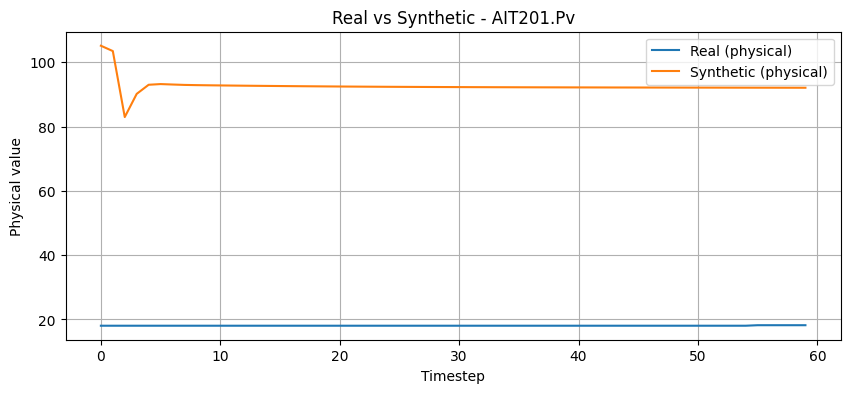

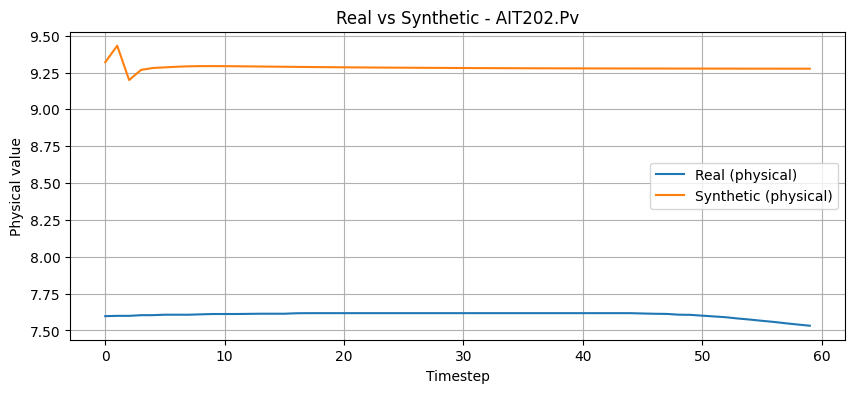

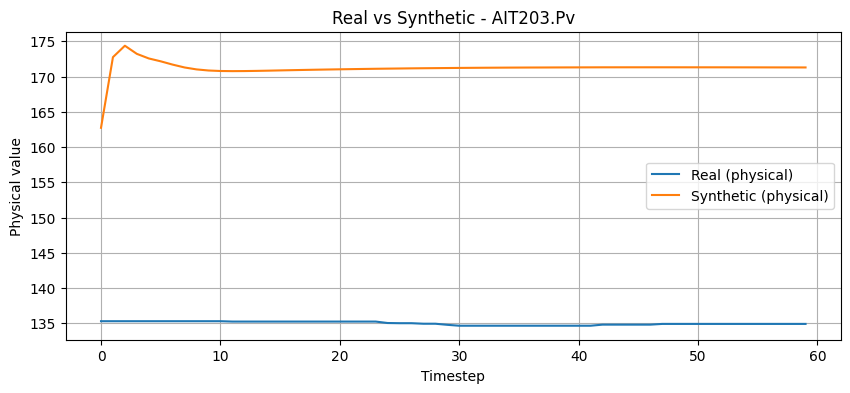

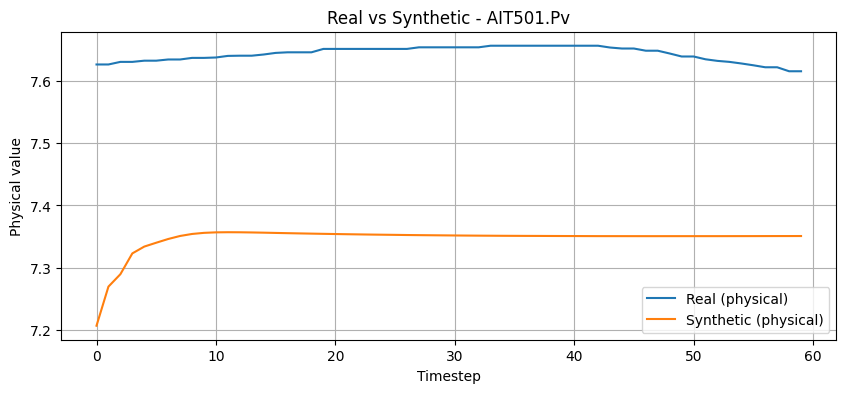

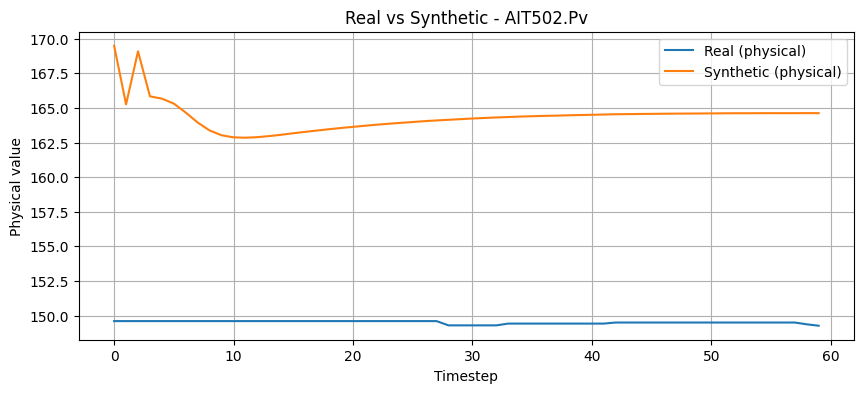

In [51]:
for i, col in enumerate(continuous_cols[:5]):
    plot_real_vs_synth_continuous_physical(
        train_cont_windows=train_cont_windows_regime,
        synthetic_cont_physical=synthetic_cont_physical,
        scaler_cont_timegan=scaler_cont_timegan,
        col_idx=i,
        col_name=col
    )

## Visualización real vs sintético de discretas

In [52]:
def plot_real_vs_synth_discrete(train_disc_raw, synthetic_disc_raw, col_idx, col_name, n_steps=60):
    real_seq = train_disc_raw[0][:n_steps, col_idx]
    synth_seq = synthetic_disc_raw[0][:n_steps, col_idx]

    plt.figure(figsize=(10, 4))
    plt.step(range(len(real_seq)), real_seq, where="post", label="Real")
    plt.step(range(len(synth_seq)), synth_seq, where="post", label="Synthetic", alpha=0.8)
    plt.title(f"Real vs Synthetic - {col_name}")
    plt.xlabel("Timestep")
    plt.ylabel("State")
    plt.grid(True)
    plt.legend()
    plt.show()

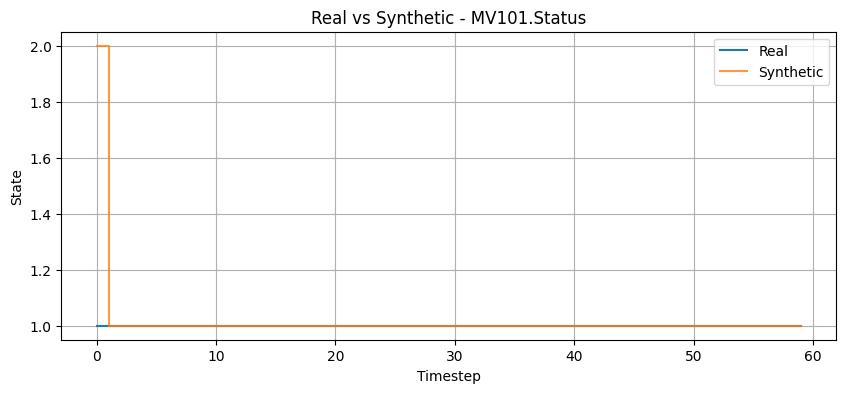

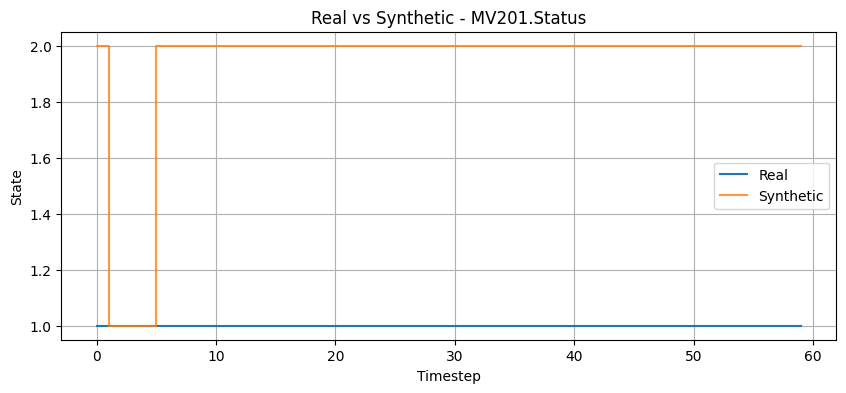

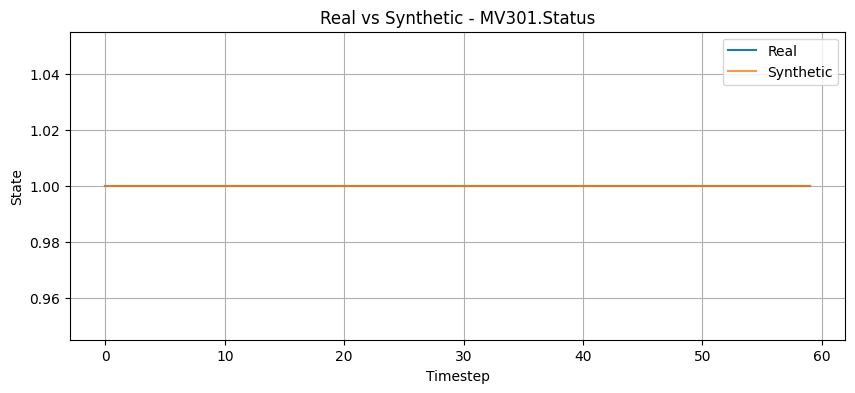

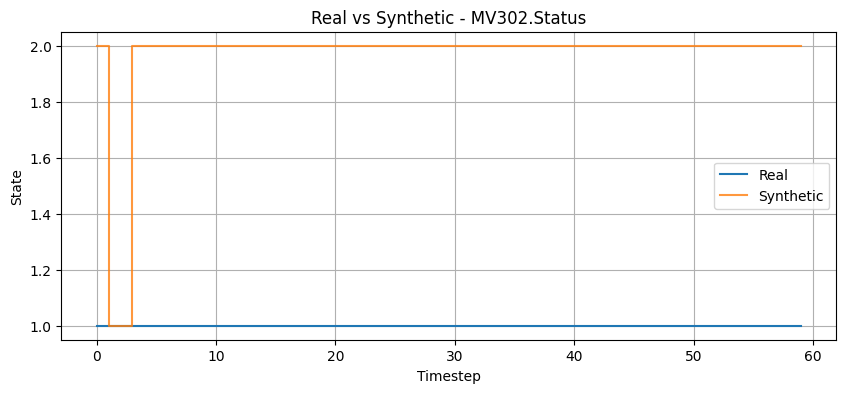

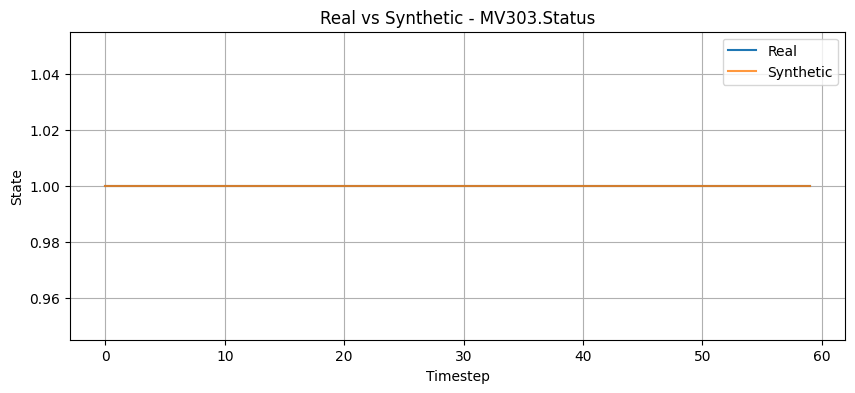

In [53]:
for j, col in enumerate(discrete_cols[:5]):
    plot_real_vs_synth_discrete(
        train_disc_raw=train_disc_windows_raw_regime,
        synthetic_disc_raw=synthetic_disc_raw,
        col_idx=j,
        col_name=col
    )

## PCA y t-SNE

In [54]:
n_plot = min(500, len(train_timegan_data_regime), len(synthetic_windows))

real_sample = train_timegan_data_regime[:n_plot].reshape(n_plot, -1)
synth_sample = synthetic_windows[:n_plot].reshape(n_plot, -1)

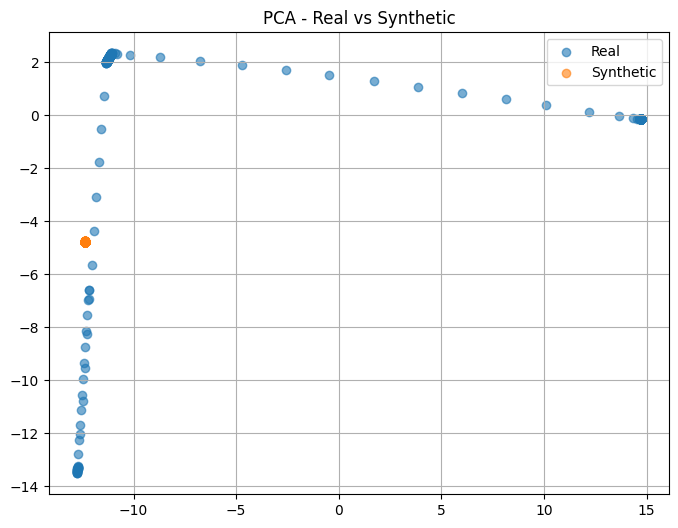

In [55]:
pca = PCA(n_components=2, random_state=SEED)
pca_real = pca.fit_transform(real_sample)
pca_synth = pca.transform(synth_sample)

plt.figure(figsize=(8, 6))
plt.scatter(pca_real[:, 0], pca_real[:, 1], alpha=0.6, label="Real")
plt.scatter(pca_synth[:, 0], pca_synth[:, 1], alpha=0.6, label="Synthetic")
plt.title("PCA - Real vs Synthetic")
plt.legend()
plt.grid(True)
plt.show()

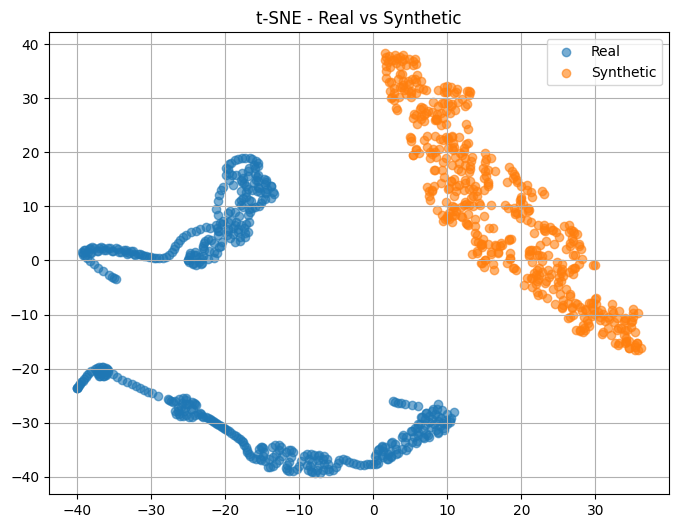

In [56]:
tsne_input = np.vstack([real_sample, synth_sample])
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, init="random", learning_rate="auto")
tsne_out = tsne.fit_transform(tsne_input)

tsne_real = tsne_out[:n_plot]
tsne_synth = tsne_out[n_plot:]

plt.figure(figsize=(8, 6))
plt.scatter(tsne_real[:, 0], tsne_real[:, 1], alpha=0.6, label="Real")
plt.scatter(tsne_synth[:, 0], tsne_synth[:, 1], alpha=0.6, label="Synthetic")
plt.title("t-SNE - Real vs Synthetic")
plt.legend()
plt.grid(True)
plt.show()

## Estadísticas de control

In [57]:
print("Synthetic full window min/max:", synthetic_windows.min(), synthetic_windows.max())
print("Synthetic continuous [0,1] min/max:", synthetic_cont_scaled.min(), synthetic_cont_scaled.max())
print("Synthetic continuous physical min/max:", synthetic_cont_physical.min(), synthetic_cont_physical.max())
print("Synthetic continuous for detector min/max:", synthetic_cont_for_detector.min(), synthetic_cont_for_detector.max())

Synthetic full window min/max: 2.4674498e-06 0.99999464
Synthetic continuous [0,1] min/max: 1.14283375e-05 0.9901814
Synthetic continuous physical min/max: 9.011614e-09 954.55536
Synthetic continuous for detector min/max: -2.297249 2.173239


## Guardado de artefactos

In [58]:
TIMEGAN_MODEL_DIR = PROJECT_ROOT / "models" / "timegan" / "conv1d_hybrid_homogeneous_regime"
TIMEGAN_MODEL_DIR.mkdir(parents=True, exist_ok=True)

In [59]:
torch.save(embedder.state_dict(), TIMEGAN_MODEL_DIR / "embedder.pt")
torch.save(recovery.state_dict(), TIMEGAN_MODEL_DIR / "recovery.pt")
torch.save(generator.state_dict(), TIMEGAN_MODEL_DIR / "generator.pt")
torch.save(supervisor.state_dict(), TIMEGAN_MODEL_DIR / "supervisor.pt")
torch.save(discriminator.state_dict(), TIMEGAN_MODEL_DIR / "discriminator.pt")

In [60]:
timegan_config = {
    "experiment_type": "homogeneous_regime",
    "aligned_detector": "conv1d_hybrid_ae",
    "best_params_used": BEST_PARAMS,
    "continuous_cols": continuous_cols,
    "discrete_cols": discrete_cols,
    "window_size": WINDOW_SIZE,
    "stride": STRIDE,
    "warmup": WARMUP,
    "regime_cols": regime_cols,
    "selected_p4": selected_p4,
    "selected_p5": selected_p5,
    "selected_p6": selected_p6,
    "selected_windows_count": int(mask_regime.sum()),
    "train_timegan_shape": list(train_timegan_data_regime.shape),
    "synthetic_windows_shape": list(synthetic_windows.shape)
}

with open(TIMEGAN_MODEL_DIR / "config.json", "w") as f:
    json.dump(timegan_config, f, indent=4)